In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('Churn_Modelling.csv')
X = dataset.iloc[:, 3:13]
y = dataset.iloc[:, 13]

In [3]:
geography=pd.get_dummies(X["Geography"],drop_first=True)
gender=pd.get_dummies(X['Gender'],drop_first=True)

In [4]:
X=pd.concat([X,geography,gender],axis=1)

## Drop Unnecessary columns
X=X.drop(['Geography','Gender'],axis=1)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [8]:
X.shape

(10000, 11)

In [9]:
X_test.shape

(2000, 11)

In [10]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [11]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [15]:
import tensorflow
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LeakyReLU,PReLU,ELU
from keras.layers import Dropout

In [16]:
classifier = Sequential()

In [17]:
classifier.add(Dense(output_dim = 6, init = 'he_uniform',activation='relu',input_dim = 11))

/Users/sheetalsuwalka/opt/anaconda3/envs/DeepNetworks/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: Update your `Dense` call to the Keras 2 API: `Dense(activation="relu", input_dim=11, units=6, kernel_initializer="he_uniform")`
  """Entry point for launching an IPython kernel.
2022-07-16 01:39:51.225762: I tensorflow/core/platform/cpu_feature_guard.cc:145] This TensorFlow binary is optimized with Intel(R) MKL-DNN to use the following CPU instructions in performance critical operations:  SSE4.1 SSE4.2
To enable them in non-MKL-DNN operations, rebuild TensorFlow with the appropriate compiler flags.
2022-07-16 01:39:51.227577: I tensorflow/core/common_runtime/process_util.cc:115] Creating new thread pool with default inter op setting: 8. Tune using inter_op_parallelism_threads for best performance.


In [18]:
classifier.add(Dense(output_dim = 6, init = 'he_uniform',activation='relu'))

/Users/sheetalsuwalka/opt/anaconda3/envs/DeepNetworks/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: Update your `Dense` call to the Keras 2 API: `Dense(activation="relu", units=6, kernel_initializer="he_uniform")`
  """Entry point for launching an IPython kernel.


In [19]:
classifier.add(Dense(output_dim = 1, init = 'glorot_uniform', activation = 'sigmoid'))

/Users/sheetalsuwalka/opt/anaconda3/envs/DeepNetworks/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: Update your `Dense` call to the Keras 2 API: `Dense(activation="sigmoid", units=1, kernel_initializer="glorot_uniform")`
  """Entry point for launching an IPython kernel.


In [20]:
classifier.compile(optimizer = 'Adamax', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [21]:
model_history=classifier.fit(X_train, y_train,validation_split=0.33, batch_size = 10, nb_epoch = 10)

/Users/sheetalsuwalka/opt/anaconda3/envs/DeepNetworks/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """Entry point for launching an IPython kernel.


Train on 5359 samples, validate on 2641 samples
Epoch 1/10
5359/5359 [==============================] - 1s 231us/step - loss: 0.6596 - accuracy: 0.6807 - val_loss: 0.4972 - val_accuracy: 0.7899
Epoch 2/10
5359/5359 [==============================] - 1s 150us/step - loss: 0.4811 - accuracy: 0.7938 - val_loss: 0.4692 - val_accuracy: 0.7917
Epoch 3/10
5359/5359 [==============================] - 1s 155us/step - loss: 0.4640 - accuracy: 0.7947 - val_loss: 0.4568 - val_accuracy: 0.7917
Epoch 4/10
5359/5359 [==============================] - 1s 150us/step - loss: 0.4525 - accuracy: 0.7998 - val_loss: 0.4473 - val_accuracy: 0.8020
Epoch 5/10
5359/5359 [==============================] - 1s 139us/step - loss: 0.4426 - accuracy: 0.8056 - val_loss: 0.4411 - val_accuracy: 0.8050
Epoch 6/10
5359/5359 [==============================] - 1s 142us/step - loss: 0.4336 - accuracy: 0.8093 - val_loss: 0.4339 - val_accuracy: 0.8167
Epoch 7/10
5359/5359 [==============================] - 1s 137us/step - loss

In [22]:
print(model_history.history.keys())

dict_keys(['val_loss', 'val_accuracy', 'loss', 'accuracy'])


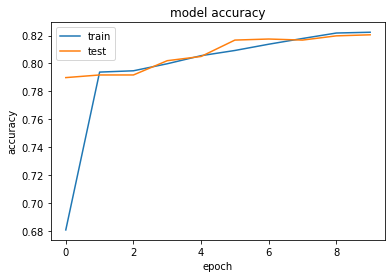

In [24]:
# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

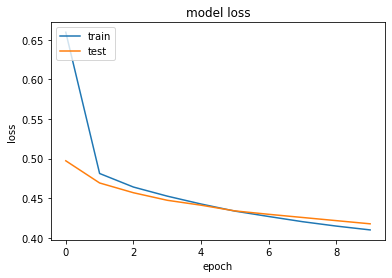

In [25]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [26]:

# Predicting the Test set results
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

In [29]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1511,   84],
       [ 272,  133]])

In [30]:
# Calculate the Accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)
score

0.822

In [3]:
dataset = pd.read_csv('Churn_Modelling.csv')

In [4]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [18]:
dataset.loc[dataset.groupby(['Geography'])['Age'].idxmax()]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6443,6444,15764927,Rogova,753,France,Male,92,3,121513.31,1,0,1,195563.99,0
3387,3388,15798024,Lori,537,Germany,Male,84,8,92242.34,1,1,1,186235.98,0
2458,2459,15813303,Rearick,513,Spain,Male,88,10,0.00,2,1,1,52952.24,0


In [58]:
dataset.index[dataset.groupby('Geography')['Age'].max()]


Int64Index([92, 84, 88], dtype='int64')

In [62]:
df1 = dataset.groupby('Geography')['Age'].max().reset_index()

In [63]:
df1.head()

,Geography,Age
0,France,92
1,Germany,84
2,Spain,88


In [66]:
dataset.loc[:,['Geography','Age']] = df1[['Geography','Age']]

In [70]:
dataset[['Geography','Age']]

,Geography,Age
0,France,92.0
1,Germany,84.0
2,Spain,88.0
3,NaN,NaN
4,NaN,NaN
...,...,...
9995,NaN,NaN
9996,NaN,NaN
9997,NaN,NaN
9998,NaN,NaN
